# HOMEWORK 12

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [95]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [96]:
plt.rcParams['figure.figsize'] = [15, 10]
sns.set_style('whitegrid')

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

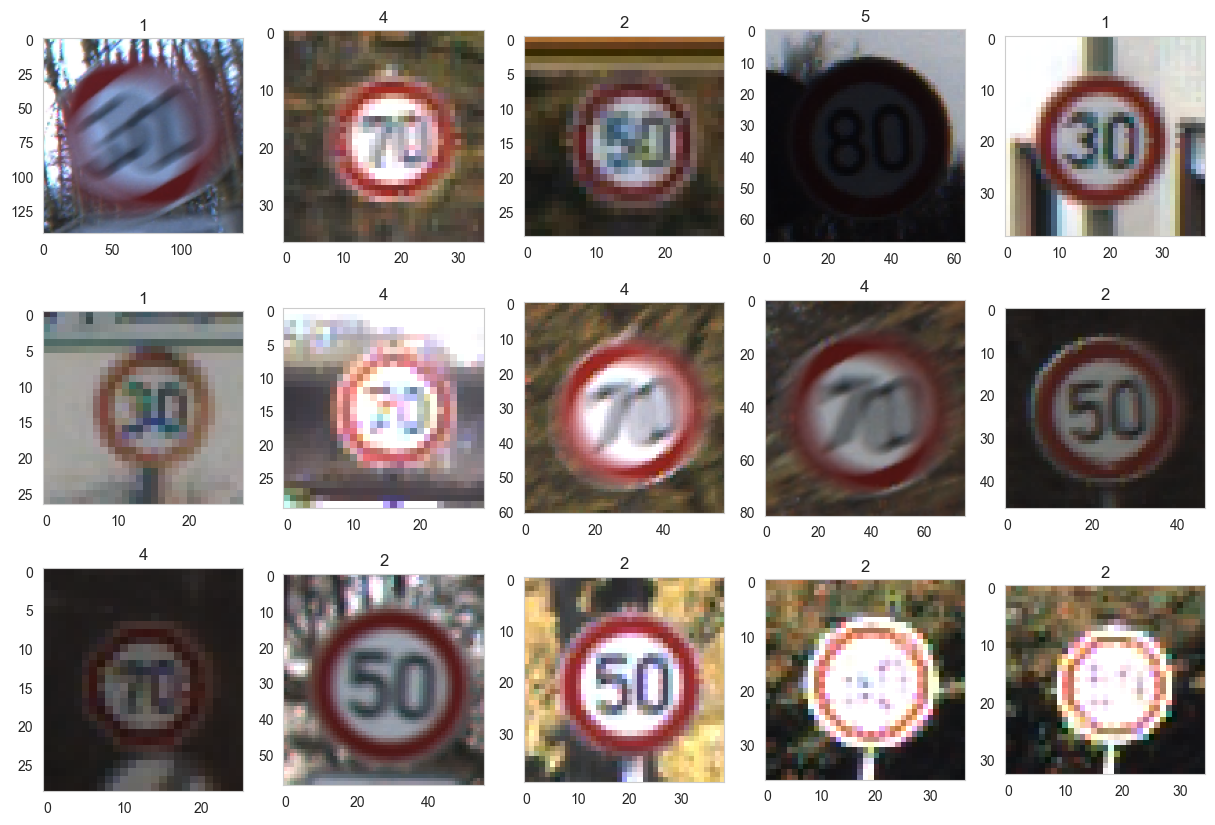

In [3]:
# Load the training labels
root = '../data/GTSRB' # Path to the dataset location, e.g., '/data/janko/dataset/GTSRB'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = 15

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, 10000)
    # Load image
    img = cv2.imread(os.path.join(root, data.iloc[idx]['Path']))
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Show image
    plt.subplot(3,5,ii+1), plt.imshow(img), plt.title(data.iloc[idx]['ClassId']), plt.grid(False)

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

In [4]:
data.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [62]:
data.shape[0]

39209

In [5]:
# Extract class identifiers
# Hint: Check the csv 
ids = data['ClassId']

Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

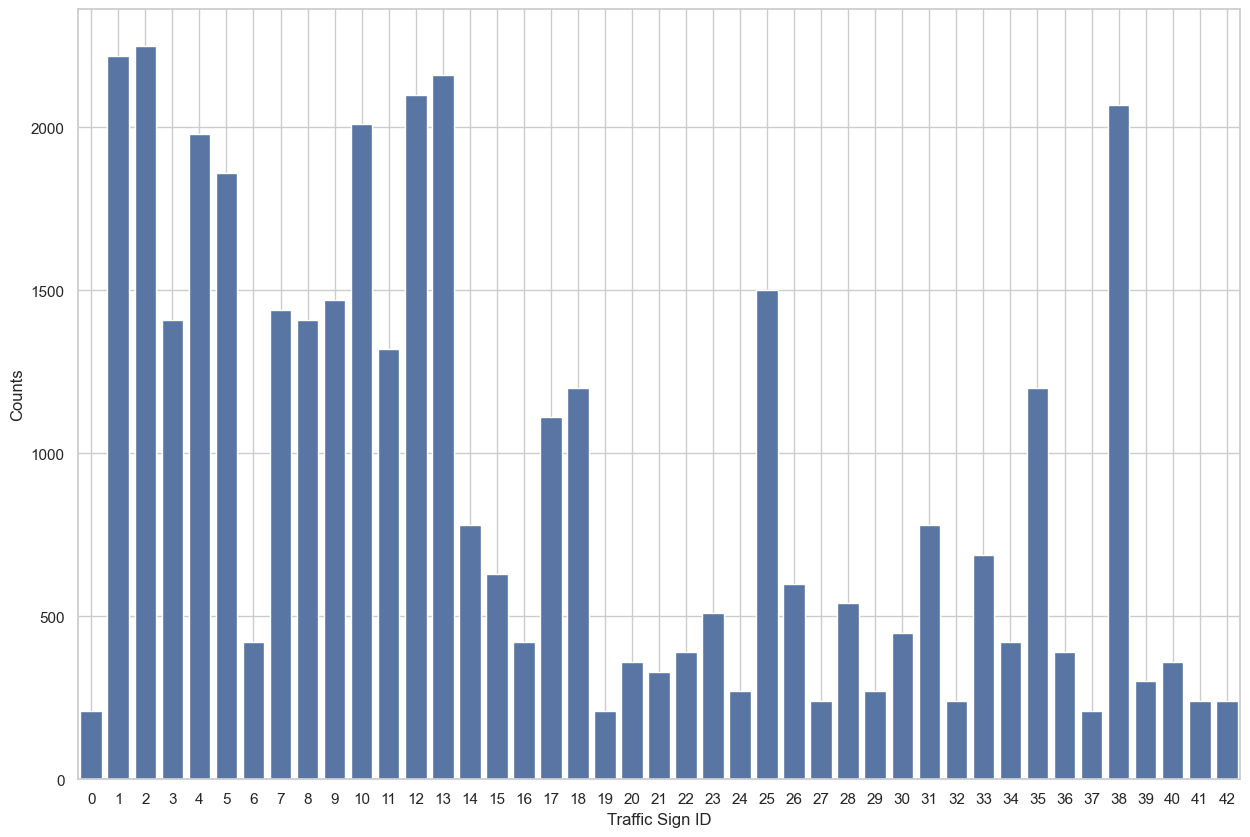

In [35]:
from collections import Counter

hist = Counter(ids)

sns.barplot(hist), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

In [7]:
# Most Common Classes
hist.most_common(10)

[(2, 2250),
 (1, 2220),
 (13, 2160),
 (12, 2100),
 (38, 2070),
 (10, 2010),
 (4, 1980),
 (5, 1860),
 (25, 1500),
 (9, 1470)]

In [52]:
# Least Common Classes
least_common = sorted(hist.items(), key=lambda x: x[1])[:10]
least_common

[(0, 210),
 (19, 210),
 (37, 210),
 (27, 240),
 (32, 240),
 (41, 240),
 (42, 240),
 (24, 270),
 (29, 270),
 (39, 300)]

### Questions

Please answer the following questions:
* Q: Do you consider the dataset to be balanced? If so, why? If not, why?
* A: Dataset is totally disbalanced. Because there are a huge disproportion by classes 2250 / 210 = *10 times !
* Q: Are there any classes that are (significantly) over-represented or under-represeneted?
* A: Classes: [2,1,13,12] are over-represented. Classes [0,19,37,27,32,41,42] are under-represented

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution? <br />
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

# Additional Analysis of GTSRB dataset

In [91]:
all_paths = data['Path'].tolist()
images = [cv2.imread(os.path.join(root, path)) for path in all_paths]
shapes = [(*img.shape, np.mean(img)) for img in images]
shape_df = pd.DataFrame(shapes, columns=['h', 'w', 'c', 'mean'])

In [155]:
shape_df['class_id'] = data['ClassId']

In [156]:
# 1. Average, Max, Min Size for Dataset ( 28x28, 40x40, 15x15 )
print(f'Height Max: {shape_df['h'].max()}, Height Min: {shape_df['h'].min()}, Width min: {shape_df['w'].min()}, Width max: {shape_df['w'].max()}')
# Images have a different sizes ( 25px smallest, 225px largest ) we need adjust

# 2. Average Contrast per image (125 +std )
print(f'Min mean: {np.round(shape_df['mean'].min(), 2)}, Max mean: {np.round(shape_df['mean'].max(), 2)}, Mean: {np.round(shape_df['mean'].mean(), 2)}')
# Images have a different ( darkest have 6.67,  highest 247 , this too large deviations ), need adjustment

# 3. Best proportion per class
best_prop = data.shape[0] / len(data['ClassId'].unique())
print(f'Best proportion per class: {np.round(best_prop, 2)}')
# Data too disbalanced ( recommended partition provided )

Height Max: 225, Height Min: 25, Width min: 25, Width max: 243
Min mean: 6.67, Max mean: 247.65, Mean: 82.77
Best proportion per class: 911.84


### Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?

In [157]:
shape_df['total_px'] = shape_df['h'] * shape_df['w']
shape_df['aspect_ratio'] = shape_df['w'] / shape_df['h']
shape_df['bins'] = pd.cut(shape_df['total_px'], 10, labels=range(10)).astype(int)

([<matplotlib.axis.XTick at 0x140a3beb4d0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

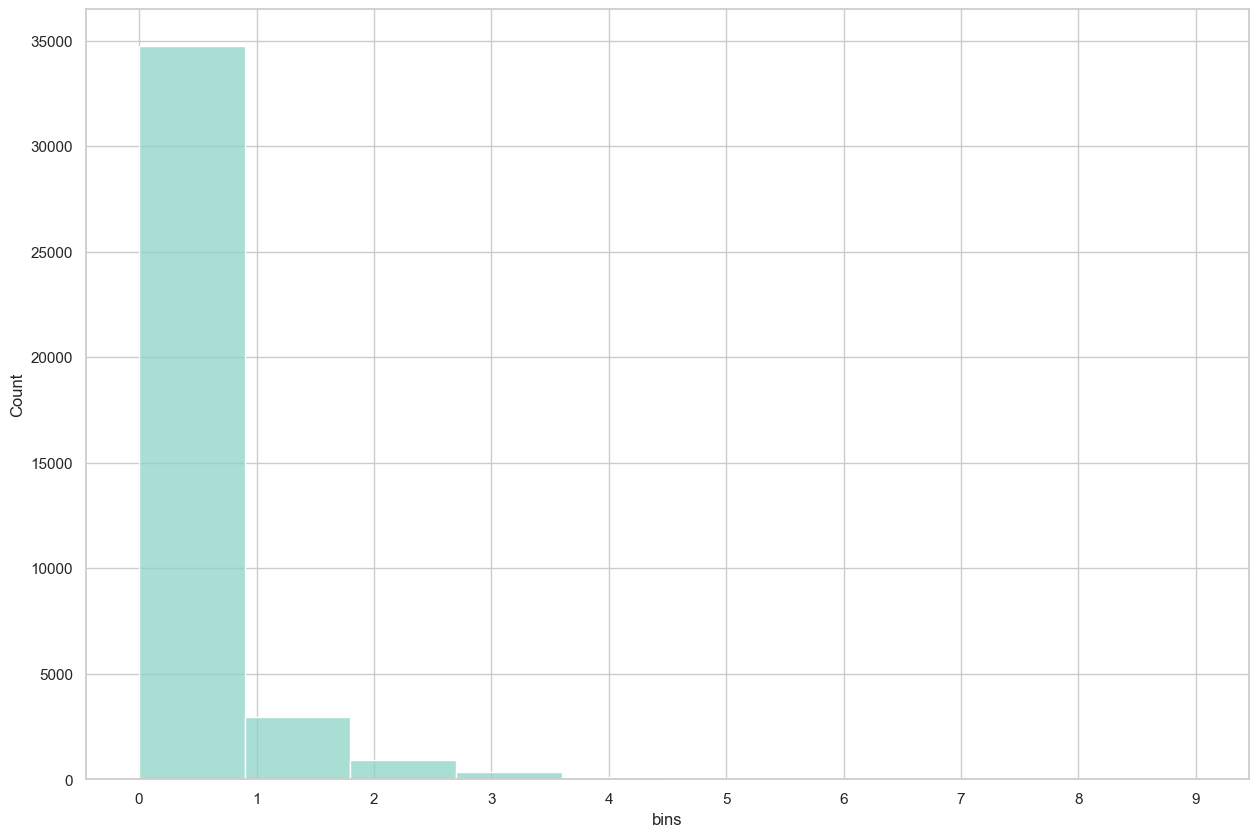

In [136]:
sns.histplot(data=shape_df['bins'], bins=10)
plt.xticks(np.arange(0, 10, 1))

In [137]:
shape_df['bins'].value_counts() / len(shape_df)
# 88% of all image have small resolution from 28x28 to 108x86 (min - 652px / max - 6005 px )

bins
0    0.886327
1    0.075187
2    0.023821
3    0.008799
4    0.003163
5    0.001658
6    0.000561
7    0.000281
8    0.000179
9    0.000026
Name: count, dtype: float64

In [153]:
grouped = shape_df.groupby('bins').agg(
    total_px__max=('total_px', 'max'),
    total_px_min=('total_px', 'min'),
    image_cnt=('bins', 'count')
)

grouped

,total_px__max,total_px_min,image_cnt
bins,,,
0,6006,625,34752
1,11433,6035,2948
2,16779,11440,934
3,22200,16851,345
4,27566,22278,124
5,32930,27692,65
6,38416,33216,22
7,43848,39000,11
8,49203,45024,7


In [150]:
shape_df[shape_df['bins'] == 0].describe()

,h,w,c,mean,total_px,bins,aspect_ratio
count,34752.000000,34752.000000,34752.0,34752.000000,34752.000000,34752.0,34752.000000
mean,43.730001,43.886769,3.0,80.254564,2070.893387,0.0,1.004087
std,12.376697,12.728482,0.0,46.480834,1219.284558,0.0,0.067114
min,25.000000,25.000000,3.0,8.136004,625.000000,0.0,0.432099
25%,34.000000,34.000000,3.0,42.958820,1155.000000,0.0,0.970588
50%,41.000000,41.000000,3.0,72.451364,1680.000000,0.0,1.000000
75%,51.000000,52.000000,3.0,110.683143,2652.000000,0.0,1.034483
max,108.000000,86.000000,3.0,247.651183,6006.000000,0.0,1.400000


### Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

In [164]:
grouped = shape_df.groupby('class_id').agg({'mean':'mean'})

Text(0.5, 1.0, 'Average lighting ( where 0 is darkest, 255 is white )')

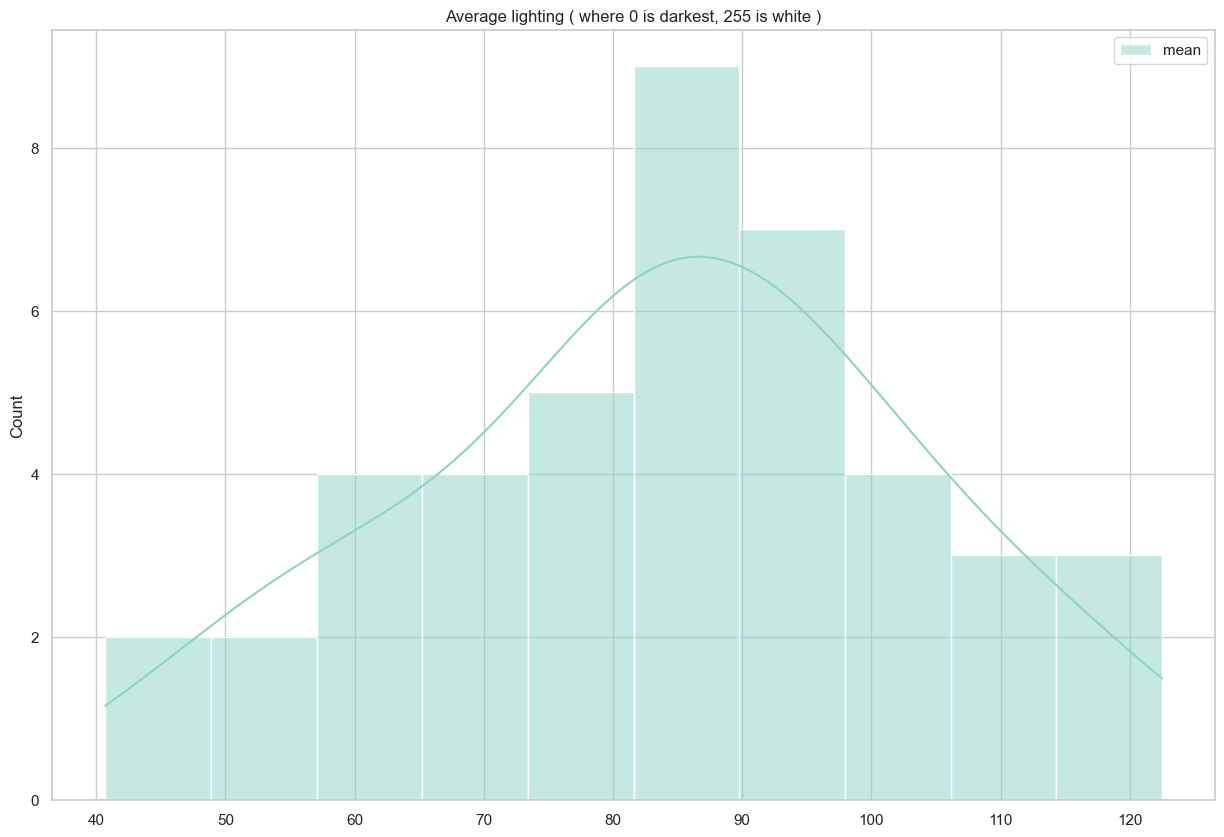

In [179]:
sns.histplot(data=grouped, bins=10, kde=True)
plt.title('Average lighting ( where 0 is darkest, 255 is white )')

In [176]:
grouped.sort_values(by='mean', ascending=False).head(10) # Top 10 Lightest Classes

,mean
class_id,
0,122.497707
34,117.389852
35,117.213985
14,110.367188
22,109.389913
1,108.513902
16,104.437595
15,101.461268
28,100.027831


In [177]:
grouped.sort_values(by='mean', ascending=True).head(10) # Top 10 Darkest Classes

,mean
class_id,
6,40.705040
8,48.037121
10,51.341462
42,52.162885
20,57.791953
7,59.372958
5,59.888980
31,60.966119
3,67.968765
